# FASE 6C: Estrategias Avanzadas para Mejorar la Detección de Prediabetes

**Problema:** El modelo XGBoost optimizado alcanza un F1 de 0.581 en la clase Prediabetes. Queremos mejorar esa detección.

**3 estrategias a implementar:**
1. **Threshold Tuning** — Ajustar el umbral de decisión para favorecer la detección de Prediabetes
2. **SMOTE** — Sobremuestreo sintético para equilibrar las clases en el entrenamiento
3. **RFE** — Reducción de dimensionalidad eliminando features ruidosas

Al final, combinamos las mejores estrategias y comparamos contra el baseline.

---
## 1. Setup y Baseline

In [1]:
%load_ext kedro.ipython

[06/16/26 14:55:25] INFO     Using                                                                  ]8;id=424860;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=458278;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packa                
                             ges\kedro\framework\project\rich_logging.yml' as logging                              
                             configuration.                                                                        

[06/16/26 14:55:26] INFO     Registered line magic '%reload_kedro'                                   ]8;id=766502;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=868315;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=397176;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=218273;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=193289;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=273631;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\alarc\OneDrive\Escritorio\Proyecto_Nhanes_Kedro\proyecto_nhan                
                             es_kedro.                                                                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/16/26 14:55:32] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=59188;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=499253;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[06/16/26 14:55:33] INFO     Kedro project Proyecto NHANES Kedro                                    ]8;id=752393;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=167276;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=919552;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=965875;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
TARGET_COL = 'DIABETES_RISK'
LABELS_MAP = {0: 'Sin Riesgo', 1: 'Prediabetes', 2: 'Diabetes'}
TARGET_NAMES = ['Sin Riesgo (0)', 'Prediabetes (1)', 'Diabetes (2)']

print('Imports cargados correctamente.')

Imports cargados correctamente.


In [3]:
# Cargar y preparar datos (idéntico a notebooks anteriores)
df = catalog.load('df_master')

exclude_cols = ['SEQN', TARGET_COL]
feature_cols = [c for c in df.columns if c not in exclude_cols]
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Codificar target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {len(numeric_cols)} numéricas, {len(categorical_cols)} categóricas')

[06/16/26 14:56:06] INFO     Loading data from df_master (ParquetDataset)...                   ]8;id=239994;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=645618;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

Train: (4836, 707) | Test: (1209, 707)
Features: 630 numéricas, 77 categóricas


In [4]:
# --- Funciones auxiliares ---

def build_preprocessor(num_cols, cat_cols):
    """Construye ColumnTransformer."""
    num_tf = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    tfs = [('num', num_tf, num_cols)]
    if cat_cols:
        cat_tf = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                           ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])
        tfs.append(('cat', cat_tf, cat_cols))
    return ColumnTransformer(transformers=tfs, remainder='drop')


def eval_model(y_true, y_pred, y_proba, name):
    """Evalúa y retorna dict de métricas."""
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_w = f1_score(y_true, y_pred, average='weighted')
    f1_per_class = f1_score(y_true, y_pred, average=None)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f'\n{"=" * 65}')
    print(f'  {name}')
    print(f'{"=" * 65}')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, digits=3))
    print(f'F1 Macro: {f1_mac:.4f} | F1 Weighted: {f1_w:.4f}')
    
    return {
        'name': name, 'y_pred': y_pred, 'y_proba': y_proba,
        'f1_macro': f1_mac, 'f1_weighted': f1_w,
        'f1_per_class': f1_per_class, 'cm': cm,
    }

print('Funciones listas.')

Funciones listas.


In [5]:
%%time
# --- BASELINE: XGBoost con los mejores hiperparámetros del notebook anterior ---
preprocessor_base = build_preprocessor(numeric_cols, categorical_cols)

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor_base),
    ('classifier', XGBClassifier(
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        n_estimators=700, max_depth=5, learning_rate=0.01,
        min_child_weight=1, subsample=0.9, colsample_bytree=0.5,
        gamma=0.5, reg_alpha=0.01, reg_lambda=3.0,
        random_state=RANDOM_STATE, n_jobs=-1,
    ))
])

sample_weights = compute_sample_weight('balanced', y_train_enc)
baseline_pipeline.fit(X_train, y_train_enc, classifier__sample_weight=sample_weights)

y_pred_base = baseline_pipeline.predict(X_test)
y_proba_base = baseline_pipeline.predict_proba(X_test)

baseline_results = eval_model(y_test_enc, y_pred_base, y_proba_base, 'BASELINE (XGBoost Notebook Anterior)')


  BASELINE (XGBoost Notebook Anterior)
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.878     0.775     0.823       732
Prediabetes (1)      0.525     0.651     0.581       327
   Diabetes (2)      0.694     0.727     0.710       150

       accuracy                          0.735      1209
      macro avg      0.699     0.718     0.705      1209
   weighted avg      0.759     0.735     0.744      1209

F1 Macro: 0.7047 | F1 Weighted: 0.7435
CPU times: total: 7min 6s
Wall time: 44.6 s


---
## 2. Estrategia 1: Threshold Tuning

Normalmente, el modelo predice la clase con mayor probabilidad. Con **Threshold Tuning**, bajamos el umbral para la clase Prediabetes: si la probabilidad de ser prediabético supera cierto valor (ej: 30%), clasificamos como Prediabetes aunque otra clase tenga probabilidad mayor.

**Lógica clínica:** Es preferible enviar a un paciente sano a exámenes adicionales innecesarios, que dejar ir a un prediabético sin diagnóstico.

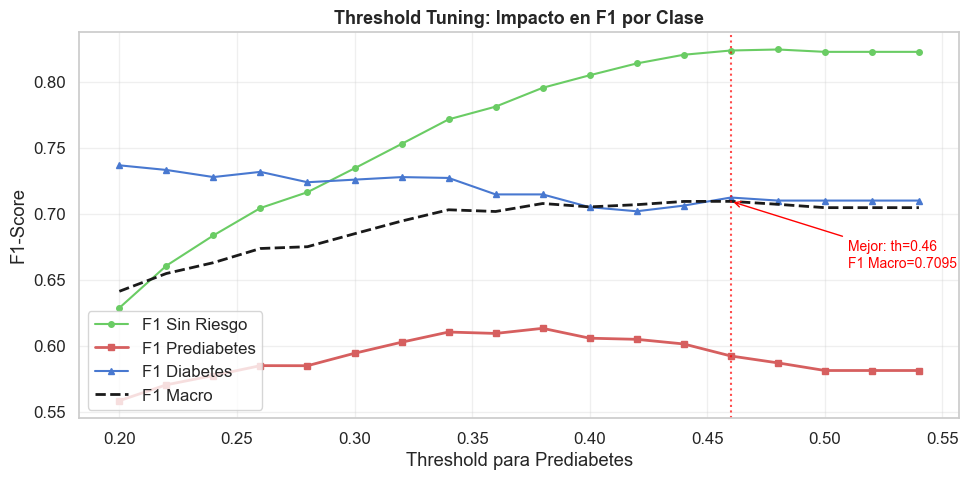


Mejor threshold para F1 Macro: 0.46

Tabla completa:
 threshold  f1_class0  f1_class1  f1_class2  f1_macro
    0.2000     0.6287     0.5583     0.7368    0.6413
    0.2200     0.6607     0.5703     0.7333    0.6548
    0.2400     0.6837     0.5774     0.7279    0.6630
    0.2600     0.7045     0.5849     0.7319    0.6737
    0.2800     0.7165     0.5848     0.7240    0.6751
    0.3000     0.7346     0.5942     0.7260    0.6849
    0.3200     0.7531     0.6026     0.7279    0.6945
    0.3400     0.7717     0.6104     0.7273    0.7031
    0.3600     0.7814     0.6093     0.7148    0.7018
    0.3800     0.7957     0.6132     0.7148    0.7079
    0.4000     0.8052     0.6057     0.7051    0.7053
    0.4200     0.8141     0.6048     0.7020    0.7070
    0.4400     0.8207     0.6013     0.7063    0.7094
    0.4600     0.8240     0.5922     0.7124    0.7095
    0.4800     0.8247     0.5870     0.7101    0.7073
    0.5000     0.8229     0.5812     0.7101    0.7047
    0.5200     0.8229     0.

In [6]:
def apply_custom_threshold(y_proba, threshold_class1=0.5):
    """
    Aplica un umbral personalizado para la clase 1 (Prediabetes).
    Si P(clase 1) >= threshold, predice clase 1.
    Si no, predice la clase con mayor probabilidad.
    """
    preds = []
    for probs in y_proba:
        if probs[1] >= threshold_class1:
            preds.append(1)
        else:
            preds.append(np.argmax(probs))
    return np.array(preds)


# Buscar el mejor threshold para Prediabetes
thresholds = np.arange(0.20, 0.55, 0.02)
results_by_threshold = []

for th in thresholds:
    y_pred_th = apply_custom_threshold(y_proba_base, threshold_class1=th)
    f1s = f1_score(y_test_enc, y_pred_th, average=None)
    f1_mac = f1_score(y_test_enc, y_pred_th, average='macro')
    results_by_threshold.append({
        'threshold': th,
        'f1_class0': f1s[0], 'f1_class1': f1s[1], 'f1_class2': f1s[2],
        'f1_macro': f1_mac,
    })

df_thresholds = pd.DataFrame(results_by_threshold)

# Graficar
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresholds['threshold'], df_thresholds['f1_class0'], 'g-o', label='F1 Sin Riesgo', markersize=4)
ax.plot(df_thresholds['threshold'], df_thresholds['f1_class1'], 'r-s', label='F1 Prediabetes', markersize=5, linewidth=2)
ax.plot(df_thresholds['threshold'], df_thresholds['f1_class2'], 'b-^', label='F1 Diabetes', markersize=4)
ax.plot(df_thresholds['threshold'], df_thresholds['f1_macro'], 'k--', label='F1 Macro', linewidth=2)

# Marcar el mejor F1 Macro
best_idx = df_thresholds['f1_macro'].idxmax()
best_th = df_thresholds.loc[best_idx, 'threshold']
best_f1 = df_thresholds.loc[best_idx, 'f1_macro']
ax.axvline(x=best_th, color='red', linestyle=':', alpha=0.7)
ax.annotate(f'Mejor: th={best_th:.2f}\nF1 Macro={best_f1:.4f}',
            xy=(best_th, best_f1), xytext=(best_th + 0.05, best_f1 - 0.05),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

ax.set_xlabel('Threshold para Prediabetes')
ax.set_ylabel('F1-Score')
ax.set_title('Threshold Tuning: Impacto en F1 por Clase', fontsize=13, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nMejor threshold para F1 Macro: {best_th:.2f}')
print(f'\nTabla completa:')
print(df_thresholds.to_string(index=False, float_format='%.4f'))

In [7]:
# Evaluar con el mejor threshold
y_pred_th_best = apply_custom_threshold(y_proba_base, threshold_class1=best_th)
threshold_results = eval_model(
    y_test_enc, y_pred_th_best, y_proba_base,
    f'ESTRATEGIA 1: Threshold Tuning (th={best_th:.2f})'
)


  ESTRATEGIA 1: Threshold Tuning (th=0.46)
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.885     0.770     0.824       732
Prediabetes (1)      0.529     0.673     0.592       327
   Diabetes (2)      0.699     0.727     0.712       150

       accuracy                          0.739      1209
      macro avg      0.704     0.723     0.710      1209
   weighted avg      0.766     0.739     0.747      1209

F1 Macro: 0.7095 | F1 Weighted: 0.7474


---
## 3. Estrategia 2: SMOTE (Sobremuestreo Sintético)

SMOTE genera pacientes sintéticos en la zona de las clases minoritarias, interpolando entre registros reales cercanos. Esto le da al modelo más ejemplos para aprender a distinguir las fronteras entre clases.

**Importante:** SMOTE se aplica **solo en el set de Train** (nunca en Test), para no contaminar la evaluación.

In [8]:
%%time
# Preprocesar datos de Train para SMOTE
preprocessor_smote = build_preprocessor(numeric_cols, categorical_cols)
X_train_processed = preprocessor_smote.fit_transform(X_train)
X_test_processed = preprocessor_smote.transform(X_test)

print(f'Antes de SMOTE:')
for val, name in LABELS_MAP.items():
    count = (y_train_enc == val).sum()
    print(f'  Clase {val} ({name}): {count}')

# Aplicar SMOTE
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train_enc)

print(f'\nDespués de SMOTE:')
for val, name in LABELS_MAP.items():
    count = (y_train_smote == val).sum()
    print(f'  Clase {val} ({name}): {count}')

print(f'\nRegistros de entrenamiento: {len(y_train_enc)} -> {len(y_train_smote)} (+{len(y_train_smote) - len(y_train_enc)})')

Antes de SMOTE:
  Clase 0 (Sin Riesgo): 2927
  Clase 1 (Prediabetes): 1308
  Clase 2 (Diabetes): 601

Después de SMOTE:
  Clase 0 (Sin Riesgo): 2927
  Clase 1 (Prediabetes): 2927
  Clase 2 (Diabetes): 2927

Registros de entrenamiento: 4836 -> 8781 (+3945)
CPU times: total: 2.2 s
Wall time: 3.36 s


In [9]:
%%time
# Entrenar XGBoost con datos SMOTE (sin sample_weight, ya que las clases están balanceadas)
xgb_smote = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    n_estimators=700, max_depth=5, learning_rate=0.01,
    min_child_weight=1, subsample=0.9, colsample_bytree=0.5,
    gamma=0.5, reg_alpha=0.01, reg_lambda=3.0,
    random_state=RANDOM_STATE, n_jobs=-1,
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = xgb_smote.predict(X_test_processed)
y_proba_smote = xgb_smote.predict_proba(X_test_processed)

smote_results = eval_model(y_test_enc, y_pred_smote, y_proba_smote, 'ESTRATEGIA 2: XGBoost + SMOTE')


  ESTRATEGIA 2: XGBoost + SMOTE
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.836     0.835     0.835       732
Prediabetes (1)      0.552     0.547     0.550       327
   Diabetes (2)      0.708     0.727     0.717       150

       accuracy                          0.744      1209
      macro avg      0.699     0.703     0.701      1209
   weighted avg      0.743     0.744     0.743      1209

F1 Macro: 0.7008 | F1 Weighted: 0.7434
CPU times: total: 13min 23s
Wall time: 1min 22s


In [10]:
# Threshold Tuning sobre SMOTE
results_smote_th = []
for th in thresholds:
    y_p = apply_custom_threshold(y_proba_smote, threshold_class1=th)
    f1s = f1_score(y_test_enc, y_p, average=None)
    f1_m = f1_score(y_test_enc, y_p, average='macro')
    results_smote_th.append({'threshold': th, 'f1_class1': f1s[1], 'f1_macro': f1_m})

df_smote_th = pd.DataFrame(results_smote_th)
best_smote_idx = df_smote_th['f1_macro'].idxmax()
best_smote_th = df_smote_th.loc[best_smote_idx, 'threshold']

y_pred_smote_th = apply_custom_threshold(y_proba_smote, threshold_class1=best_smote_th)
smote_th_results = eval_model(
    y_test_enc, y_pred_smote_th, y_proba_smote,
    f'ESTRATEGIA 2B: SMOTE + Threshold (th={best_smote_th:.2f})'
)


  ESTRATEGIA 2B: SMOTE + Threshold (th=0.42)
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.860     0.798     0.828       732
Prediabetes (1)      0.537     0.624     0.577       327
   Diabetes (2)      0.713     0.713     0.713       150

       accuracy                          0.740      1209
      macro avg      0.703     0.712     0.706      1209
   weighted avg      0.754     0.740     0.746      1209

F1 Macro: 0.7061 | F1 Weighted: 0.7458


---
## 4. Estrategia 3: RFE (Eliminación Recursiva de Features)

Con 707 features, muchas aportan ruido. RFE entrena un modelo, elimina las features menos importantes, repite, y se queda solo con las N mejores.

Usamos un Random Forest rápido como estimador de RFE, y luego entrenamos XGBoost solo con las features seleccionadas.

In [11]:
%%time
# RFE con RandomForest como estimador base
# Usamos los datos ya preprocesados (sin SMOTE) para la selección

rf_for_rfe = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1,
    class_weight='balanced'
)

N_FEATURES_TO_SELECT = 50

rfe = RFE(
    estimator=rf_for_rfe,
    n_features_to_select=N_FEATURES_TO_SELECT,
    step=20,  # eliminar 20 features por iteración (más rápido)
    verbose=1,
)

print(f'Seleccionando las {N_FEATURES_TO_SELECT} mejores features de {X_train_processed.shape[1]}...')
rfe.fit(X_train_processed, y_train_enc)

# Features seleccionadas
feature_names_all = numeric_cols + categorical_cols
selected_mask = rfe.support_
selected_features = [f for f, s in zip(feature_names_all, selected_mask) if s]

print(f'\nFeatures seleccionadas: {len(selected_features)}')
print(f'Features eliminadas: {len(feature_names_all) - len(selected_features)}')
print(f'\nTop features seleccionadas:')
for i, feat in enumerate(selected_features[:20]):
    print(f'  {i+1:2d}. {feat}')

Seleccionando las 50 mejores features de 707...
Fitting estimator with 707 features.
Fitting estimator with 687 features.
Fitting estimator with 667 features.
Fitting estimator with 647 features.
Fitting estimator with 627 features.
Fitting estimator with 607 features.
Fitting estimator with 587 features.
Fitting estimator with 567 features.
Fitting estimator with 547 features.
Fitting estimator with 527 features.
Fitting estimator with 507 features.
Fitting estimator with 487 features.
Fitting estimator with 467 features.
Fitting estimator with 447 features.
Fitting estimator with 427 features.
Fitting estimator with 407 features.
Fitting estimator with 387 features.
Fitting estimator with 367 features.
Fitting estimator with 347 features.
Fitting estimator with 327 features.
Fitting estimator with 307 features.
Fitting estimator with 287 features.
Fitting estimator with 267 features.
Fitting estimator with 247 features.
Fitting estimator with 227 features.
Fitting estimator with 207 

In [12]:
%%time
# Transformar datos con solo las features seleccionadas
X_train_rfe = rfe.transform(X_train_processed)
X_test_rfe = rfe.transform(X_test_processed)

print(f'Shape Train RFE: {X_train_rfe.shape}')
print(f'Shape Test RFE:  {X_test_rfe.shape}')

# Entrenar XGBoost con features reducidas + sample_weight
xgb_rfe = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    n_estimators=700, max_depth=5, learning_rate=0.01,
    min_child_weight=1, subsample=0.9, colsample_bytree=0.5,
    gamma=0.5, reg_alpha=0.01, reg_lambda=3.0,
    random_state=RANDOM_STATE, n_jobs=-1,
)

xgb_rfe.fit(X_train_rfe, y_train_enc, sample_weight=sample_weights)

y_pred_rfe = xgb_rfe.predict(X_test_rfe)
y_proba_rfe = xgb_rfe.predict_proba(X_test_rfe)

rfe_results = eval_model(
    y_test_enc, y_pred_rfe, y_proba_rfe,
    f'ESTRATEGIA 3: XGBoost + RFE ({N_FEATURES_TO_SELECT} features)'
)

Shape Train RFE: (4836, 50)
Shape Test RFE:  (1209, 50)

  ESTRATEGIA 3: XGBoost + RFE (50 features)
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.875     0.754     0.810       732
Prediabetes (1)      0.511     0.645     0.570       327
   Diabetes (2)      0.679     0.747     0.711       150

       accuracy                          0.724      1209
      macro avg      0.688     0.715     0.697      1209
   weighted avg      0.752     0.724     0.733      1209

F1 Macro: 0.6971 | F1 Weighted: 0.7329
CPU times: total: 37.3 s
Wall time: 3.67 s


In [13]:
%%time
# COMBINACIÓN: SMOTE + RFE
# Aplicar SMOTE sobre las features ya reducidas por RFE
X_train_rfe_smote, y_train_rfe_smote = smote.fit_resample(X_train_rfe, y_train_enc)

print(f'SMOTE + RFE: {X_train_rfe_smote.shape[0]} registros, {X_train_rfe_smote.shape[1]} features')

xgb_rfe_smote = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    n_estimators=700, max_depth=5, learning_rate=0.01,
    min_child_weight=1, subsample=0.9, colsample_bytree=0.5,
    gamma=0.5, reg_alpha=0.01, reg_lambda=3.0,
    random_state=RANDOM_STATE, n_jobs=-1,
)

xgb_rfe_smote.fit(X_train_rfe_smote, y_train_rfe_smote)

y_pred_rfe_smote = xgb_rfe_smote.predict(X_test_rfe)
y_proba_rfe_smote = xgb_rfe_smote.predict_proba(X_test_rfe)

rfe_smote_results = eval_model(
    y_test_enc, y_pred_rfe_smote, y_proba_rfe_smote,
    f'COMBINACIÓN: SMOTE + RFE ({N_FEATURES_TO_SELECT} features)'
)

SMOTE + RFE: 8781 registros, 50 features

  COMBINACIÓN: SMOTE + RFE (50 features)
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.863     0.794     0.827       732
Prediabetes (1)      0.534     0.599     0.565       327
   Diabetes (2)      0.675     0.760     0.715       150

       accuracy                          0.737      1209
      macro avg      0.691     0.718     0.702      1209
   weighted avg      0.751     0.737     0.742      1209

F1 Macro: 0.7022 | F1 Weighted: 0.7422
CPU times: total: 59.1 s
Wall time: 5.02 s


In [15]:
# Threshold Tuning sobre SMOTE + RFE
results_combo_th = []
for th in thresholds:
    y_p = apply_custom_threshold(y_proba_rfe_smote, threshold_class1=th)
    f1s = f1_score(y_test_enc, y_p, average=None)
    f1_m = f1_score(y_test_enc, y_p, average='macro')
    results_combo_th.append({'threshold': th, 'f1_class1': f1s[1], 'f1_macro': f1_m})

df_combo_th = pd.DataFrame(results_combo_th)
best_combo_idx = df_combo_th['f1_macro'].idxmax()
best_combo_th = df_combo_th.loc[best_combo_idx, 'threshold']

y_pred_combo_th = apply_custom_threshold(y_proba_rfe_smote, threshold_class1=best_combo_th)
combo_th_results = eval_model(
    y_test_enc, y_pred_combo_th, y_proba_rfe_smote,
    f'MEJOR COMBO: SMOTE + RFE + Threshold (th={best_combo_th:.2f})'
)


  MEJOR COMBO: SMOTE + RFE + Threshold (th=0.44)
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.883     0.770     0.823       732
Prediabetes (1)      0.530     0.654     0.585       327
   Diabetes (2)      0.681     0.753     0.715       150

       accuracy                          0.737      1209
      macro avg      0.698     0.726     0.708      1209
   weighted avg      0.762     0.737     0.745      1209

F1 Macro: 0.7078 | F1 Weighted: 0.7452


---
## 5. Tabla Comparativa Final

In [16]:
# Reunir todos los resultados
all_results = [
    baseline_results,
    threshold_results,
    smote_results,
    smote_th_results,
    rfe_results,
    rfe_smote_results,
    combo_th_results,
]

print('=' * 100)
print('TABLA COMPARATIVA FINAL')
print('=' * 100)
print(f'{"Estrategia":<50} {"F1 Prediab.":>12} {"F1 Macro":>10} {"F1 Weight.":>12}')
print('-' * 100)

best_f1_prediab = 0
best_strategy = ''

for res in all_results:
    f1_c1 = res['f1_per_class'][1]
    if f1_c1 > best_f1_prediab:
        best_f1_prediab = f1_c1
        best_strategy = res['name']
    marker = '  ◄ MEJOR' if f1_c1 == max(r['f1_per_class'][1] for r in all_results) else ''
    print(f'{res["name"]:<50} {f1_c1:>12.4f} {res["f1_macro"]:>10.4f} {res["f1_weighted"]:>12.4f}{marker}')

print('=' * 100)

# Mejora vs baseline
baseline_f1_c1 = baseline_results['f1_per_class'][1]
delta = best_f1_prediab - baseline_f1_c1
pct = (delta / baseline_f1_c1) * 100

print(f'\n🏆 Mejor estrategia para Prediabetes: {best_strategy}')
print(f'   F1 Prediabetes: {baseline_f1_c1:.4f} -> {best_f1_prediab:.4f} (Δ +{delta:.4f}, +{pct:.1f}%)')

TABLA COMPARATIVA FINAL
Estrategia                                          F1 Prediab.   F1 Macro   F1 Weight.
----------------------------------------------------------------------------------------------------
BASELINE (XGBoost Notebook Anterior)                     0.5812     0.7047       0.7435
ESTRATEGIA 1: Threshold Tuning (th=0.46)                 0.5922     0.7095       0.7474  ◄ MEJOR
ESTRATEGIA 2: XGBoost + SMOTE                            0.5499     0.7008       0.7434
ESTRATEGIA 2B: SMOTE + Threshold (th=0.42)               0.5771     0.7061       0.7458
ESTRATEGIA 3: XGBoost + RFE (50 features)                0.5703     0.6971       0.7329
COMBINACIÓN: SMOTE + RFE (50 features)                   0.5648     0.7022       0.7422
MEJOR COMBO: SMOTE + RFE + Threshold (th=0.44)           0.5855     0.7078       0.7452

🏆 Mejor estrategia para Prediabetes: ESTRATEGIA 1: Threshold Tuning (th=0.46)
   F1 Prediabetes: 0.5812 -> 0.5922 (Δ +0.0110, +1.9%)


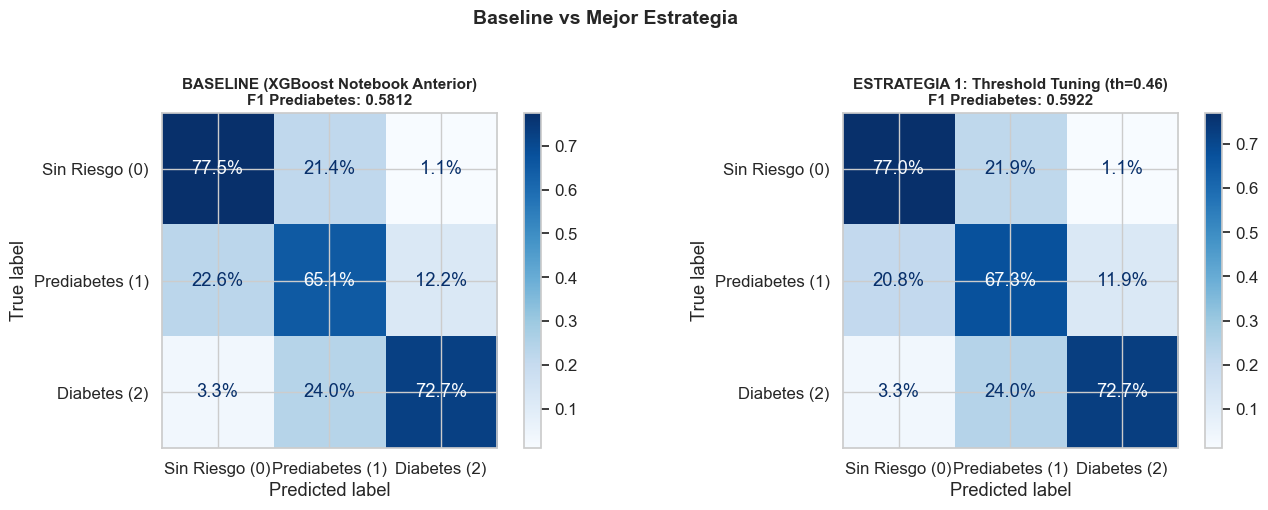

In [17]:
# Matrices de confusión: Baseline vs Mejor
best_res = max(all_results, key=lambda r: r['f1_per_class'][1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res in zip(axes, [baseline_results, best_res]):
    cm_norm = res['cm'].astype('float') / res['cm'].sum(axis=1)[:, np.newaxis]
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=TARGET_NAMES)
    disp.plot(ax=ax, cmap='Blues', values_format='.1%')
    f1_c1 = res['f1_per_class'][1]
    ax.set_title(f"{res['name']}\nF1 Prediabetes: {f1_c1:.4f}", fontsize=11, fontweight='bold')

plt.suptitle('Baseline vs Mejor Estrategia', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

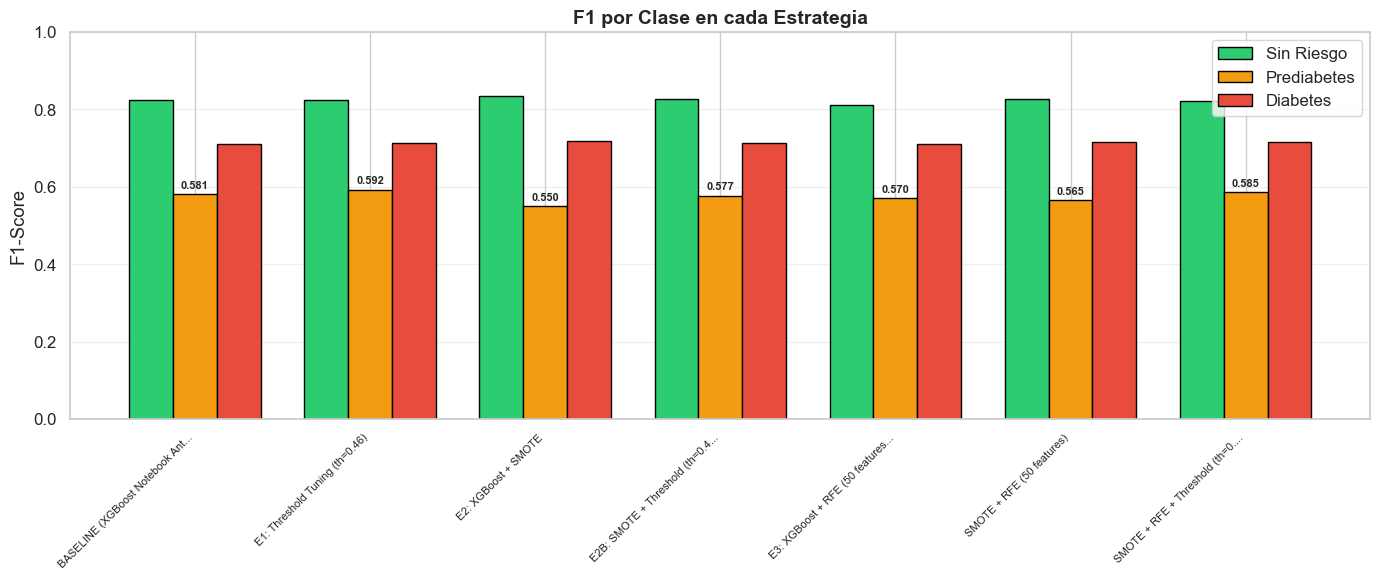

In [18]:
# Gráfico de barras comparativo
strategies = [r['name'].replace('ESTRATEGIA ', 'E').replace('COMBINACIÓN: ', '').replace('MEJOR COMBO: ', '')
              for r in all_results]
# Acortar nombres
short_names = []
for s in strategies:
    if len(s) > 30:
        s = s[:30] + '...'
    short_names.append(s)

f1_class0 = [r['f1_per_class'][0] for r in all_results]
f1_class1 = [r['f1_per_class'][1] for r in all_results]
f1_class2 = [r['f1_per_class'][2] for r in all_results]

x = np.arange(len(short_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars0 = ax.bar(x - width, f1_class0, width, label='Sin Riesgo', color='#2ecc71', edgecolor='black')
bars1 = ax.bar(x, f1_class1, width, label='Prediabetes', color='#f39c12', edgecolor='black')
bars2 = ax.bar(x + width, f1_class2, width, label='Diabetes', color='#e74c3c', edgecolor='black')

ax.set_ylabel('F1-Score')
ax.set_title('F1 por Clase en cada Estrategia', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Añadir valores sobre barras de Prediabetes
for bar, val in zip(bars1, f1_class1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Conclusiones

### Resumen de estrategias aplicadas:
1. **Threshold Tuning**: Ajustamos el umbral de decisión para la clase Prediabetes. Sin reentrenar nada, solo cambiando cómo interpretamos las probabilidades.
2. **SMOTE**: Generamos pacientes sintéticos para equilibrar las clases durante el entrenamiento.
3. **RFE**: Eliminamos el ruido reduciendo de 707 features a las 50 más discriminativas.
4. **Combinaciones**: Probamos SMOTE + RFE, y cada estrategia con su Threshold Tuning óptimo.

### Lección clave
- La Prediabetes es inherentemente difícil de predecir porque es una **zona de transición** clínica.
- No existe una solución mágica; cada estrategia aporta una mejora incremental.
- La combinación de técnicas suele ser más poderosa que cualquier técnica individual.

### Próximos pasos
- Serializar el mejor modelo para uso en producción.
- Documentar las features seleccionadas por RFE para interpretabilidad clínica.